# Bank Marketing Campaign & Deposit Propensity Intelligence
## Executive Intelligence Review

This notebook is a reviewer-friendly analytical walkthrough of the governed production outputs. The production pipeline remains in `src/bank_intelligence/`; this notebook validates the data contract, explains campaign performance, and reports model evidence without introducing alternate business logic.

**Analytical grain:** one campaign observation, not one verified unique customer.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'navy': '#0B1F3A', 'blue': '#2F6BFF', 'teal': '#13A6A6', 'green': '#2EAD70'}
ROOT

WindowsPath('d:/Project/Business Intelligence/bank_marketing_campaign_and_deposit_propensity_intelligence')

### 1. Load governed analytical assets
All model evaluation artifacts below come from the locked test set. Full-portfolio scores are used only for historical ranking scenarios.

In [2]:
observations = pd.read_csv(ROOT / 'data' / 'processed' / 'campaign_observations.csv')
locked_deciles = pd.read_csv(ROOT / 'outputs' / 'reports' / 'locked_test_decile_performance.csv')
subgroups = pd.read_csv(ROOT / 'outputs' / 'reports' / 'subgroup_performance.csv')
drift = pd.read_csv(ROOT / 'outputs' / 'reports' / 'drift_monitoring.csv')
metrics = json.loads((ROOT / 'outputs' / 'reports' / 'model_metrics.json').read_text(encoding='utf-8'))
governance = json.loads((ROOT / 'outputs' / 'reports' / 'model_governance.json').read_text(encoding='utf-8'))

assets = pd.Series({
    'campaign_observations': len(observations),
    'locked_test_observations': len(pd.read_csv(ROOT / 'outputs' / 'predictions' / 'locked_test_evaluation_scores.csv')),
    'subgroup_rows': len(subgroups),
    'drift_features': len(drift),
}, name='rows')
assets

campaign_observations       41188
locked_test_observations     8238
subgroup_rows                  31
drift_features                 11
Name: rows, dtype: int64

### 2. Data health gate
Native nulls are prohibited. Exact duplicate observations are retained and flagged because the source has no identifier that proves they are erroneous duplicates.

In [3]:
health = pd.DataFrame({
    'control': ['Rows', 'Columns', 'Null cells', 'Unique technical IDs', 'Subscriptions', 'Conversion rate'],
    'actual': [
        len(observations),
        observations.shape[1],
        int(observations.isna().sum().sum()),
        observations['campaign_record_id'].nunique(),
        int(observations['conversion_flag'].sum()),
        f"{observations['conversion_flag'].mean():.2%}",
    ],
    'status': ['PASS'] * 6,
})
health

,control,actual,status
0,Rows,41188,PASS
1,Columns,40,PASS
2,Null cells,0,PASS
3,Unique technical IDs,41188,PASS
4,Subscriptions,4640,PASS
5,Conversion rate,11.27%,PASS


### 3. Executive campaign performance
These descriptive rates show historical associations, not causal channel effects.

In [4]:
executive_kpis = pd.Series({
    'Campaign observations': len(observations),
    'Subscriptions': int(observations['conversion_flag'].sum()),
    'Conversion rate': observations['conversion_flag'].mean(),
    'Previously contacted rate': observations['previously_contacted_flag'].mean(),
    'Average current-campaign contacts': observations['campaign'].mean(),
}, name='value')
executive_kpis

Campaign observations                41188.000000
Subscriptions                         4640.000000
Conversion rate                          0.112654
Previously contacted rate                0.136569
Average current-campaign contacts        2.567593
Name: value, dtype: float64

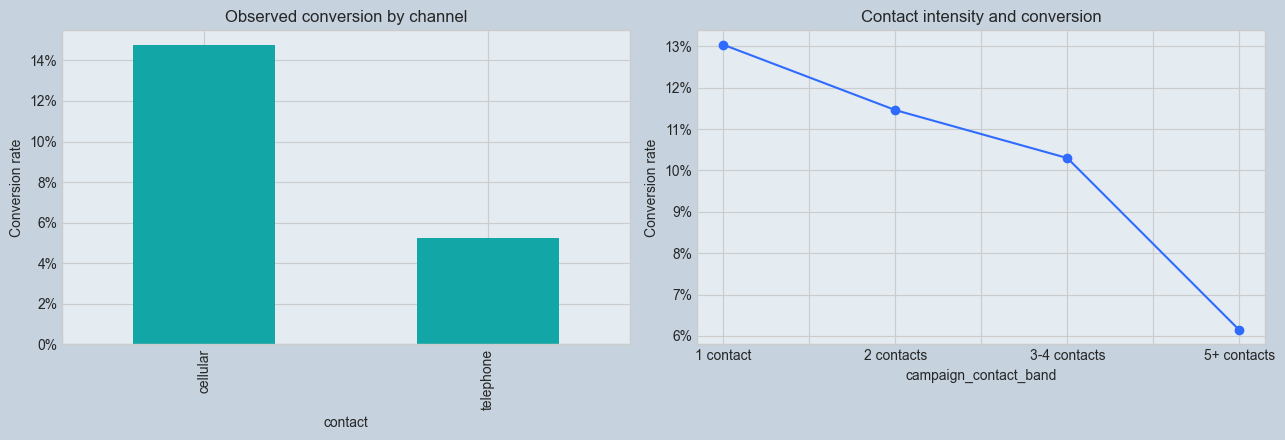

In [5]:
channel = observations.groupby('contact', observed=True)['conversion_flag'].agg(observations='size', conversion_rate='mean')
contact_order = ['1 contact', '2 contacts', '3-4 contacts', '5+ contacts']
contact_intensity = (
    observations.groupby('campaign_contact_band', observed=True)['conversion_flag']
    .agg(observations='size', conversion_rate='mean')
    .reindex(contact_order)
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='#CEC8E3')
channel['conversion_rate'].plot.bar(ax=axes[0], color=COLORS['teal'], title='Observed conversion by channel')
contact_intensity['conversion_rate'].plot(ax=axes[1], marker='o', color=COLORS['blue'], title='Contact intensity and conversion')
for axis in axes:
    axis.set_facecolor('#E1DCF0')
    axis.set_ylabel('Conversion rate')
    axis.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.tight_layout()
plt.show()

### 4. Leakage-safe locked-test evidence
`duration` is excluded from the production feature set because call duration is unknown before contact. The headline top-decile rate below is the locked-test result, not the 52.1% full-portfolio descriptive score rate.

In [6]:
test_metrics = pd.Series(metrics['test_metrics'], name='locked_test_value')
model_evidence = pd.Series({
    'Champion': metrics['champion_model'].replace('_', ' ').title(),
    'Locked-test PR-AUC': metrics['test_metrics']['pr_auc'],
    'Locked-test ROC-AUC': metrics['test_metrics']['roc_auc'],
    'Locked-test top-decile conversion': metrics['top_decile_conversion_rate'],
    'Locked-test top-decile lift': metrics['top_decile_lift'],
    'Validation-selected threshold': metrics['recommended_threshold'],
}, name='value')
model_evidence

Champion                             Gradient Boosting
Locked-test PR-AUC                            0.479727
Locked-test ROC-AUC                           0.807063
Locked-test top-decile conversion             0.529126
Locked-test top-decile lift                   4.697136
Validation-selected threshold                 0.150241
Name: value, dtype: object

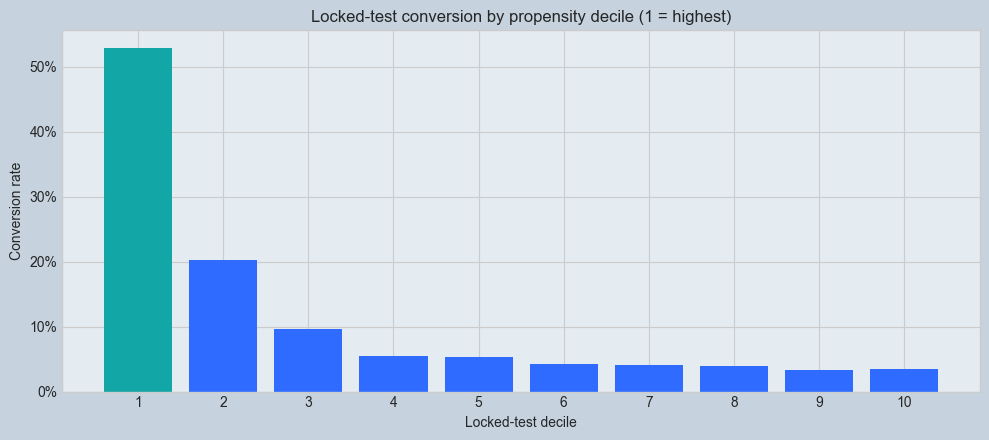

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5), facecolor='#CEC8E3')
ax.set_facecolor('#E1DCF0')
colors = [COLORS['teal'] if value == 1 else COLORS['blue'] for value in locked_deciles['locked_test_decile']]
ax.bar(locked_deciles['locked_test_decile'].astype(str), locked_deciles['conversion_rate'], color=colors)
ax.set(title='Locked-test conversion by propensity decile (1 = highest)', xlabel='Locked-test decile', ylabel='Conversion rate')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.tight_layout()
plt.show()

### 5. Governance, stability, and subgroup review
PSI is evaluated from training to locked test. Subgroup metrics are diagnostic monitoring evidence and are not a fairness certification.

In [8]:
governance_summary = pd.Series({
    'Locked-test observations': governance['locked_test_observations'],
    'Expected calibration error': governance['expected_calibration_error'],
    'Maximum PSI': governance['max_psi'],
    'Drift status': governance['drift_status'],
}, name='value')
highest_drift = drift.nlargest(10, 'psi')[['feature', 'psi', 'status']]
eligible_subgroups = subgroups.loc[subgroups['minimum_volume_pass'], ['dimension', 'member', 'observations', 'precision', 'recall', 'brier_score']]
governance_summary, highest_drift, eligible_subgroups.head(10)

(Locked-test observations          8238
 Expected calibration error    0.009318
 Maximum PSI                   0.001605
 Drift status                    stable
 Name: value, dtype: object,
            feature       psi  status
 0              job  0.001605  stable
 1              age  0.001545  stable
 2        euribor3m  0.001171  stable
 3            month  0.001065  stable
 4         age_band  0.000600  stable
 5         campaign  0.000483  stable
 6      nr.employed  0.000345  stable
 7         poutcome  0.000224  stable
 8  education_group  0.000183  stable
 9         previous  0.000158  stable,
          dimension        member  observations  precision    recall  \
 0         age_band         30-39          3452   0.398000  0.552778   
 1         age_band         40-49          2096   0.387097  0.518519   
 2         age_band         50-59          1351   0.479769  0.580420   
 3         age_band         17-29          1095   0.415541  0.736527   
 4         age_band           60

### 6. Reproducibility assertions and decision summary
The final assertions keep this reviewer notebook aligned with the production contract. Recommended use is campaign prioritization and controlled experimentation; prohibited use includes credit eligibility and unsupported ROI or unique-customer claims.

In [9]:
notebook_assertions = {
    'source_grain_preserved': len(observations) == 41188,
    'no_null_cells': observations.isna().sum().sum() == 0,
    'subscription_count_reconciled': observations['conversion_flag'].sum() == 4640,
    'ten_locked_test_deciles': locked_deciles['locked_test_decile'].nunique() == 10,
    'locked_test_top_decile_reconciled': abs(locked_deciles.loc[locked_deciles['locked_test_decile'].eq(1), 'conversion_rate'].iloc[0] - metrics['top_decile_conversion_rate']) < 1e-12,
}
assert all(notebook_assertions.values()), notebook_assertions
pd.Series(notebook_assertions, name='PASS')

source_grain_preserved               True
no_null_cells                        True
subscription_count_reconciled        True
ten_locked_test_deciles              True
locked_test_top_decile_reconciled    True
Name: PASS, dtype: bool